## Pendekatan Tertutup

Metode pendekatan tertutup dilakukan dengan membatasi nilai estimasi akar ($x_r$) yang berada dalam rentang tertentu, batas bawah ($x_i$) dan  batas atas ($x_f$). Pada artikel ini akan membahas dua metode numerik untuk menghitung nilai akar yaitu, Metode Bagi Dua (Biseksi) dan Metode Regula Falsi.

### Metode Bagi Dua (Biseksi)

Perhitungan nilai akar ($x_r$) persamaan menggunakan metode biseksi dilakukan dengan membagi dua dengan persamaan

$x_r = \frac {x_i + x_f} {2}$

dari rentang batas yang didefinisikan $[x_i, x_f]$, dimana $x_i$ adalah batas awal dan $x_r$ adalah batas akhir. Jika $f(x_i) . f(x_f) < 0$, maka diasumsikan nilai akar, $x_r$, berada pada rentang $[x_i, x_f]$. Jika $x_r$ tidak berada dalam rentang yang didefinisikan, maka harus dipilih nilai batas yang baru.

**Algoritma Metode Biseksi**

1. Definisikan nilai batas awal ($x_i$) dan batas akhir ($x_f$) estimasi akar
2. Definisikan nilai toleransi, $tol = 0.001$
3. Definisikan nilai error awal, $error = 1$
4. Jika $f(xi) . f(xf) < 0$
   
   5.1 Selama $error > tol$ maka lakukan proses berikut
   
   - Hitung nilai akar, $x_r = \frac {x_i + x_f} {2}$
    
   - Jika $f(x_r) = 0$
      
      - akarnya adalah $x_r$.
      - $error = 0$
      - proses dihentikan

   - Jika $f(x_i) . f(x_r) < 0$
     - maka, $x_{old} = x_f$, dan $x_f = x_r$
   - Jika $f(x_i) . f(x_r) > 0$
     - maka, $x_{old} = x_i$, dan $x_i = x_r$
  
   5.2 Hitung nilai galat (error), $error = |\frac {x_r - x_{old}}{x_r}|$
  
   5.3 Jika $error$ > $tol$, proses 5.1 - 5.3 diulang

**Contoh Kasus**

Estimasi nilai $x$ yang memenuhi persamaan kuadrat $x^2 + 2x - 3 = 0$!

Jika persamaan tersebut diselesaikan dengan pendekatan analitik, persamaan kuadrat tersebut memiliki dua akar yang berbeda tanda, yaitu $x_1 = -3$ dan $x_2 = 1$.

Maka dari itu, kita bisa uji dengan menggunakan metode biseksi (bisection method) dimana batas nilai akar dapat didefinisikan dalam rentang batas awal $x_i = -5$ dan batas akhir $x_f = 0$. Asumsi batas toleransi sebesar $1e^{-3}$.


In [1]:
# Ini fungsi untuk hitung error
def cal_absolute_error(xr,xold):
  return abs((xr-xold)/xr)

In [2]:
# Ini fungsi untuk plot grafik

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

def plot_graphic(xmin, xmax, f, xroot, iterations, errors, title=None, xlabel='x'):
  x = np.linspace(xmin, xmax, 20)

  fig, ax = plt.subplots(figsize=(10,4), ncols=2)

  if title != None:
    plt.suptitle(f"{title}", fontsize=16)

  ax[0].plot(x, f(x), color='k', linewidth=2, label='f(x)')
  ax[0].plot(xroot, f(xroot), '.', color='red', markersize=10, label='root')
  ax[0].set_xlabel(xlabel)
  ax[0].set_ylabel('f(x)')
  # ax[0].xaxis.set_minor_locator(MultipleLocator(0.2))
  # ax[0].yaxis.set_minor_locator(MultipleLocator(1))
  ax[0].grid(which='both')
  ax[0].legend(loc='best')


  ax[1].plot(iterations, errors, color='k', linewidth=2)
  ax[1].set_xlabel('Iteration')
  ax[1].set_ylabel('Absolute Error')
  ax[1].xaxis.set_minor_locator(MultipleLocator(0.5))
  ax[1].yaxis.set_minor_locator(MultipleLocator(0.1))
  ax[1].grid(which='both')

  plt.tight_layout()


Nilai akar berada dalam rentang

Error: 1.00000, xr: -2.50000, f(xr): -1.75000
Error: 1.00000, xr: -3.75000, f(xr): 3.56250
Error: 0.33333, xr: -3.12500, f(xr): 0.51562
Error: 0.20000, xr: -2.81250, f(xr): -0.71484
Error: 0.11111, xr: -2.96875, f(xr): -0.12402
Error: 0.05263, xr: -3.04688, f(xr): 0.18970
Error: 0.02564, xr: -3.00781, f(xr): 0.03131
Error: 0.01299, xr: -2.98828, f(xr): -0.04674
Error: 0.00654, xr: -2.99805, f(xr): -0.00781
Error: 0.00326, xr: -3.00293, f(xr): 0.01173
Error: 0.00163, xr: -3.00049, f(xr): 0.00195

Jumlah perulangan (iterasi): 11
Nilai akar, xr: -3.000
f(xr) = 0.002, error = 0.0008


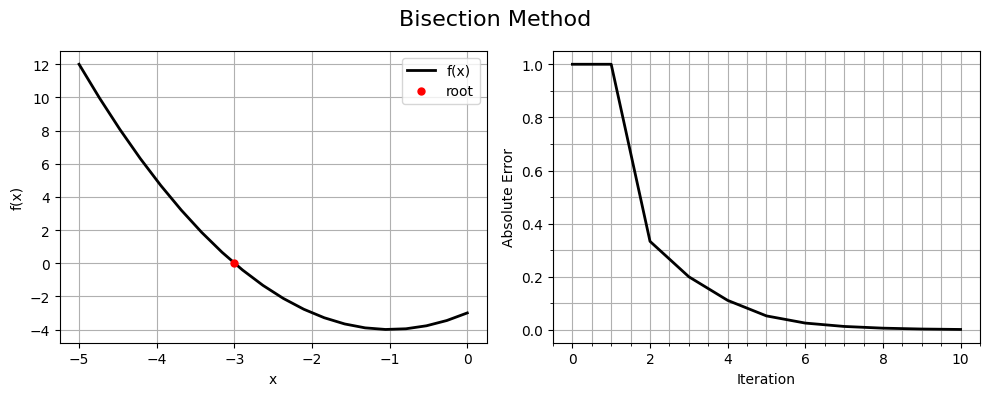

In [5]:
# Metode Biseksi (Bagi Dua)
# input batas akar
xi = -5 # batas awal
xf = 0 # batas akhir

# nilai toleransi error
tol = 1e-3
error = 1

# Jumlah iterasi
iter = 0

# definisikan fungsi kuadrat
f = lambda x : x**2 + (2*x) - 3

iteration, errors = [], []
if (f(xi) * f(xf)) < 0:
  print()
  print("Nilai akar berada dalam rentang")
  print()

  while error > tol:
    iteration.append(iter)
    errors.append(error)
    # hitung estimasi nilai akar awal
    xr = (xi + xf) / 2

    if f(xr) == 0:
      x_old = xr
      error = 0
      print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
      iter += 1
      break
    elif f(xi) * f(xr) < 0:
      x_old, xf = xf, xr
    elif f(xi) * f(xr) > 0:
      x_old, xi = xi, xr

    print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)
    iter += 1

  print()
  print(f"Jumlah perulangan (iterasi): {iter}")
  print(f"Nilai akar, xr: {xr:.3f}")
  print(f"f(xr) = {f(xr):.3f}, error = {error:.4f}")
else:
  print("Masukan batas nilai yang baru")

# Plot grafik
plot_graphic(-5,0,f,xr,iteration, errors, title='Bisection Method')